# 02 - Arhitektura i trening modela
Definišemo i treniramo MLP neuronsku mrežu za detekciju prevara kreditnim karticama.

**Autor: Nikola**

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.neural_network import MLPClassifier
from sklearn.metrics import confusion_matrix, classification_report, roc_auc_score, RocCurveDisplay, PrecisionRecallDisplay
import seaborn as sb

## Učitavanje preprocesiranih podataka
Učitavamo podatke koji su pripremljeni u prvom notebooku — skalirani i SMOTE-balansirani trening set.

In [2]:
X_train_sm = pd.read_csv('../data/X_train.csv')
X_test = pd.read_csv('../data/X_test.csv')
y_train_sm = pd.read_csv('../data/y_train.csv').values.ravel()
y_test = pd.read_csv('../data/y_test.csv').values.ravel()

print(f"X_train: {X_train_sm.shape}")
print(f"X_test: {X_test.shape}")

X_train: (454902, 30)
X_test: (56962, 30)


## Definisanje i trening modela
Koristimo MLP (Multi-Layer Perceptron) sa tri skrivena sloja (64, 32, 16 neurona), ReLU aktivacionom funkcijom.

In [3]:
model = MLPClassifier(
    hidden_layer_sizes=(64, 32, 16),
    activation='relu',
    max_iter=50,
    random_state=42,
    verbose=True
)

model.fit(X_train_sm, y_train_sm)


Iteration 1, loss = 0.03023209
Iteration 2, loss = 0.00450010
Iteration 3, loss = 0.00313942
Iteration 4, loss = 0.00241271
Iteration 5, loss = 0.00220622
Iteration 6, loss = 0.00198747
Iteration 7, loss = 0.00163315
Iteration 8, loss = 0.00137735
Iteration 9, loss = 0.00153837
Iteration 10, loss = 0.00111471
Iteration 11, loss = 0.00146227
Iteration 12, loss = 0.00104704
Iteration 13, loss = 0.00107094
Iteration 14, loss = 0.00104553
Iteration 15, loss = 0.00086735
Iteration 16, loss = 0.00098410
Iteration 17, loss = 0.00081488
Iteration 18, loss = 0.00077437
Iteration 19, loss = 0.00091476
Iteration 20, loss = 0.00067000
Iteration 21, loss = 0.00061598
Iteration 22, loss = 0.00071118
Iteration 23, loss = 0.00078071
Iteration 24, loss = 0.00051104
Iteration 25, loss = 0.00062460
Iteration 26, loss = 0.00068995
Iteration 27, loss = 0.00050787
Iteration 28, loss = 0.00063795
Iteration 29, loss = 0.00057209
Iteration 30, loss = 0.00054452
Iteration 31, loss = 0.00068145
Iteration 32, los

,"hidden_layer_sizes hidden_layer_sizes: array-like of shape(n_layers - 2,), default=(100,)The ith element represents the number of neurons in the ithhidden layer.","(64, ...)"
,"activation activation: {'identity', 'logistic', 'tanh', 'relu'}, default='relu'Activation function for the hidden layer.- 'identity', no-op activation, useful to implement linear bottleneck, returns f(x) = x- 'logistic', the logistic sigmoid function, returns f(x) = 1 / (1 + exp(-x)).- 'tanh', the hyperbolic tan function, returns f(x) = tanh(x).- 'relu', the rectified linear unit function, returns f(x) = max(0, x)",'relu'
,"solver solver: {'lbfgs', 'sgd', 'adam'}, default='adam'The solver for weight optimization.- 'lbfgs' is an optimizer in the family of quasi-Newton methods.- 'sgd' refers to stochastic gradient descent.- 'adam' refers to a stochastic gradient-based optimizer proposed by Kingma, Diederik, and Jimmy BaFor a comparison between Adam optimizer and SGD, see:ref:`sphx_glr_auto_examples_neural_networks_plot_mlp_training_curves.py`.Note: The default solver 'adam' works pretty well on relativelylarge datasets (with thousands of training samples or more) in terms ofboth training time and validation score.For small datasets, however, 'lbfgs' can converge faster and performbetter.",'adam'
,"alpha alpha: float, default=0.0001Strength of the L2 regularization term. The L2 regularization termis divided by the sample size when added to the loss.For an example usage and visualization of varying regularization, see:ref:`sphx_glr_auto_examples_neural_networks_plot_mlp_alpha.py`.",0.0001
,"batch_size batch_size: int, default='auto'Size of minibatches for stochastic optimizers.If the solver is 'lbfgs', the classifier will not use minibatch.When set to ""auto"", `batch_size=min(200, n_samples)`.",'auto'
,"learning_rate learning_rate: {'constant', 'invscaling', 'adaptive'}, default='constant'Learning rate schedule for weight updates.- 'constant' is a constant learning rate given by 'learning_rate_init'.- 'invscaling' gradually decreases the learning rate at each time step 't' using an inverse scaling exponent of 'power_t'. effective_learning_rate = learning_rate_init / pow(t, power_t)- 'adaptive' keeps the learning rate constant to 'learning_rate_init' as long as training loss keeps decreasing. Each time two consecutive epochs fail to decrease training loss by at least tol, or fail to increase validation score by at least tol if 'early_stopping' is on, the current learning rate is divided by 5.Only used when ``solver='sgd'``.",'constant'
,"learning_rate_init learning_rate_init: float, default=0.001The initial learning rate used. It controls the step-sizein updating the weights. Only used when solver='sgd' or 'adam'.",0.001
,"power_t power_t: float, default=0.5The exponent for inverse scaling learning rate.It is used in updating effective learning rate when the learning_rateis set to 'invscaling'. Only used when solver='sgd'.",0.5
,"max_iter max_iter: int, default=200Maximum number of iterations. The solver iterates until convergence(determined by 'tol') or this number of iterations. For stochasticsolvers ('sgd', 'adam'), note that this determines the number of epochs(how many times each data point will be used), not the number ofgradient steps.",50
,"shuffle shuffle: bool, default=TrueWhether to shuffle samples in each iteration. Only used whensolver='sgd' or 'adam'.",True
,"random_state random_state: int, RandomState instance, default=NoneDetermines random number generation for weights and biasinitialization, train-test split if early stopping is used, and batchsampling when solver='sgd' or 'adam'.Pass an int for reproducible results across multiple function calls.See :term:`Glossary `.",42


## Evaluacija modela
Primenjujemo model na test set i prikazujemo confusion matrix i izveštaj klasifikacije.

In [4]:
y_pred = model.predict(X_test)
y_prob = model.predict_proba(X_test)[:, 1]

print(confusion_matrix(y_test, y_pred))
print(classification_report(y_test, y_pred))

[[56828    36]
 [   14    84]]
              precision    recall  f1-score   support

           0       1.00      1.00      1.00     56864
           1       0.70      0.86      0.77        98

    accuracy                           1.00     56962
   macro avg       0.85      0.93      0.89     56962
weighted avg       1.00      1.00      1.00     56962



## Vizualizacija confusion matrice
Grafički prikaz tačnih i pogrešnih klasifikacija modela.

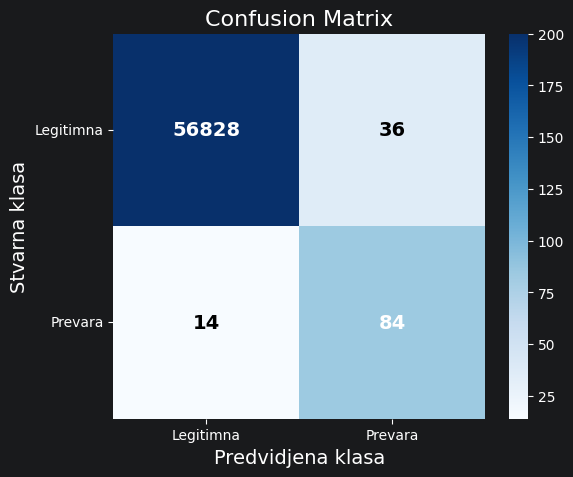

In [5]:
cm = confusion_matrix(y_test, y_pred)

fig, ax = plt.subplots(figsize=(6,5))

sb.heatmap(
    cm,
    annot=False,
    cmap='Blues',
    xticklabels=['Legitimna', 'Prevara'],
    yticklabels=['Legitimna', 'Prevara'],
    cbar=True,
    vmax=200
)

for i in range(cm.shape[0]):
    for j in range(cm.shape[1]):
        ax.text(
            j + 0.5,
            i + 0.5,
            str(cm[i, j]),
            ha='center',
            va='center',
            color='white' if cm[i, j] > 40 else 'black',
            fontsize=14,
            fontweight='bold'
        )

plt.title('Confusion Matrix', fontsize=16)
plt.ylabel('Stvarna klasa', fontsize=14)
plt.xlabel('Predvidjena klasa', fontsize=14)
plt.yticks(rotation=0)
plt.show()

In [6]:
print(cm)
print(cm.shape)

[[56828    36]
 [   14    84]]
(2, 2)


## ROC kriva
ROC kriva prikazuje odnos između stope tačno detektovanih prevara i stope lažnih uzbuna na svim mogućim pragovima odlučivanja.

AUC-ROC: 0.964


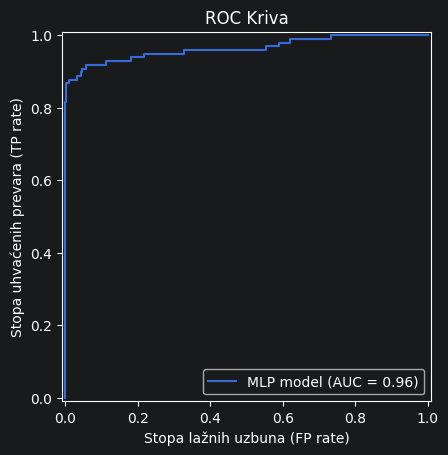

In [7]:
print(f"AUC-ROC: {roc_auc_score(y_test, y_prob):.3f}")

RocCurveDisplay.from_predictions(
    y_test, y_prob,
    name='MLP model'
)
plt.title('ROC Kriva')
plt.xlabel('Stopa lažnih uzbuna (FP rate)')
plt.ylabel('Stopa uhvaćenih prevara (TP rate)')
plt.show()

## Precision-Recall kriva
Precision-Recall kriva je važnija od ROC krive za neuravnotežene datasete — direktno prikazuje kompromis između preciznosti i odziva modela.

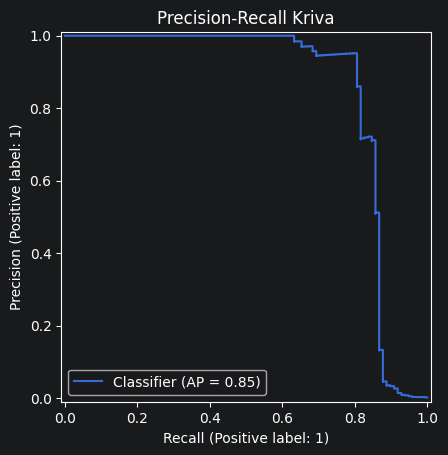

In [8]:
PrecisionRecallDisplay.from_predictions(y_test, y_prob)
plt.title('Precision-Recall Kriva')
plt.show()